<a href="https://colab.research.google.com/github/Deepikadandolu/SumInt_IISc_ex1/blob/main/tumor_svm(linear)_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.


In [3]:
# Define classes and labels
classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3}
# Dataset training folder path
train_path = os.path.join(path, "Training")
# Load and preprocess dataset
X = []
Y = []
for cls, label in classes.items():
    class_path = os.path.join(train_path, cls)
    for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)
        # Read image in grayscale
        img = cv2.imread(img_path, 0)
        if img is not None:
            # Resize image
            img = cv2.resize(img, (200, 200))
            # Normalize image
            img = img / 255.0
            # Flatten image
            X.append(img.flatten())
            # Append label
            Y.append(label)
# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

print("Dataset loaded successfully")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Dataset loaded successfully
X shape: (2870, 40000)
Y shape: (2870,)


In [4]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.8)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("20-80 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

20-80 Split
Training Score: 1.0
Testing Score: 0.7221254355400697


In [5]:
# Split the dataset 40-60
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.6)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("40-60 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

40-60 Split
Training Score: 1.0
Testing Score: 0.7619047619047619


In [6]:
# Split the dataset into 60-40
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.4)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("60-40 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

60-40 Split
Training Score: 1.0
Testing Score: 0.7700348432055749


In [7]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.2)
# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("80-20 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

80-20 Split
Training Score: 1.0
Testing Score: 0.8013937282229965



Predictions using LINEAR SVM - 20-80 Split


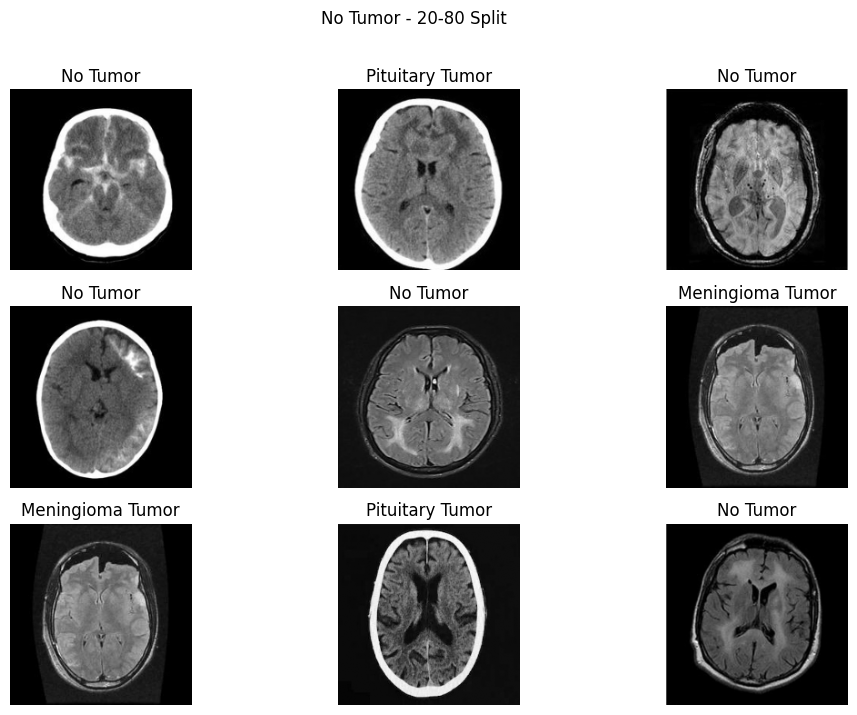

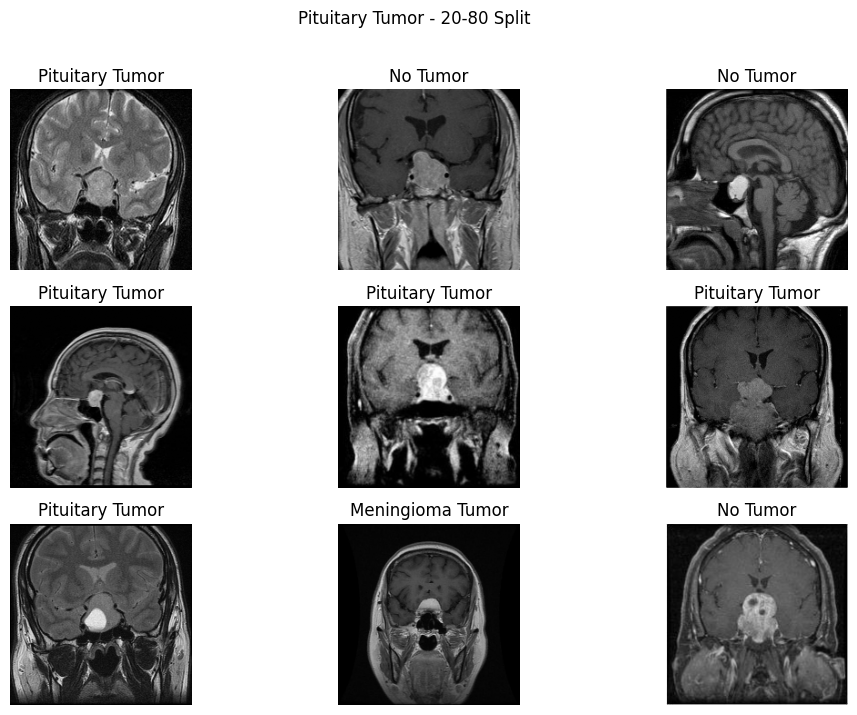

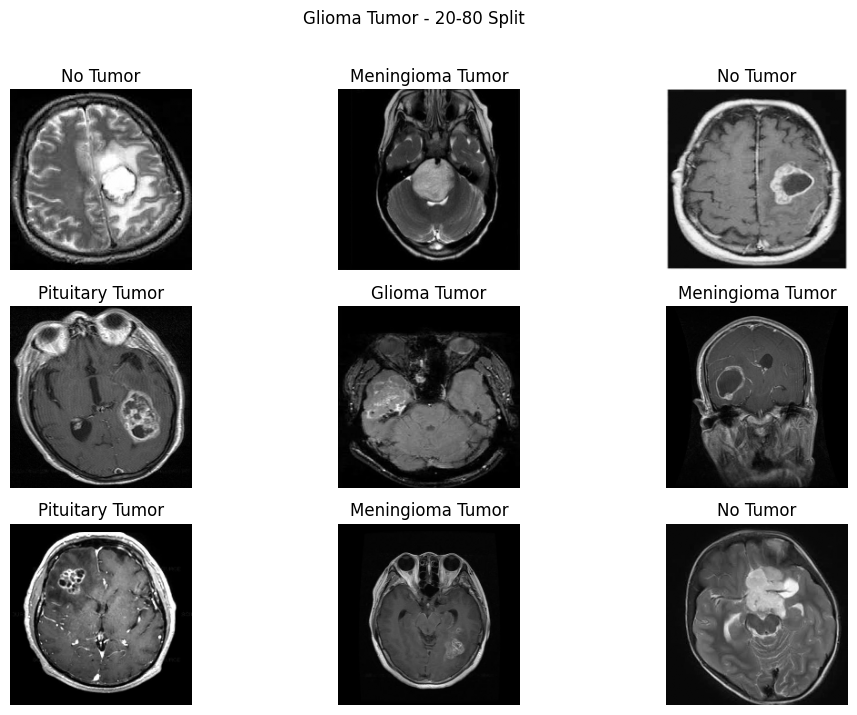

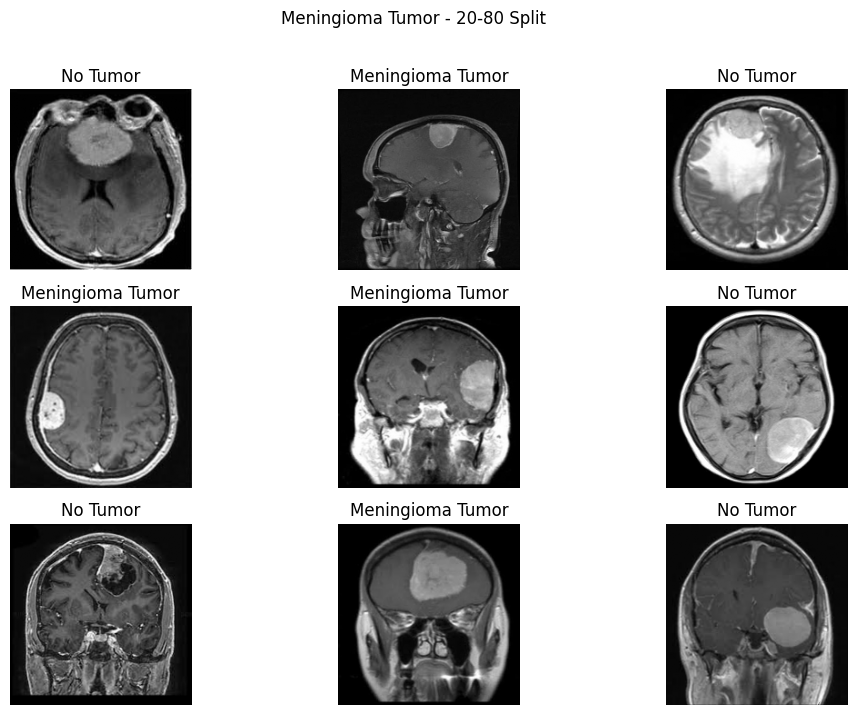


Predictions using LINEAR SVM - 40-60 Split


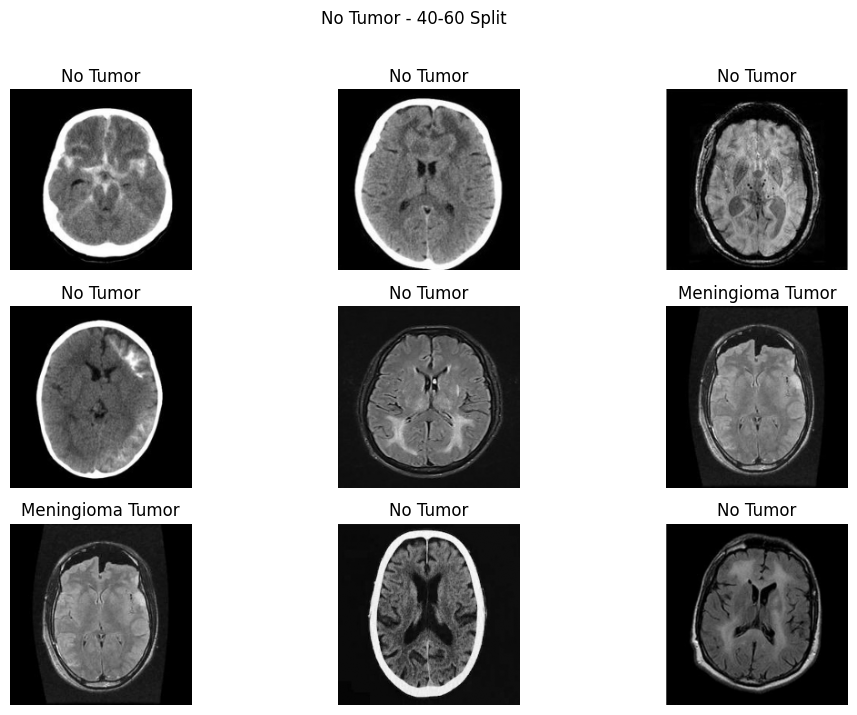

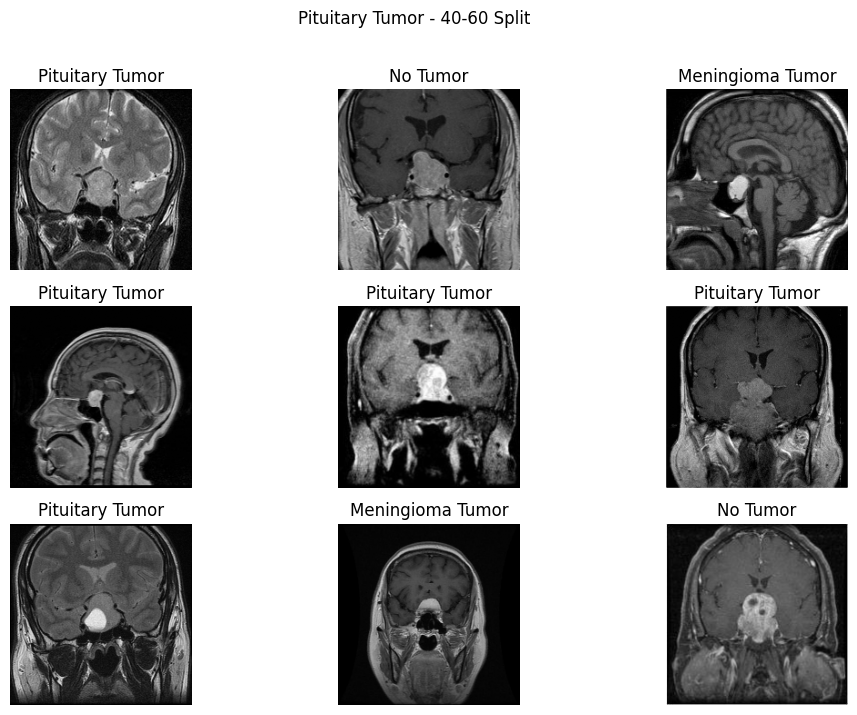

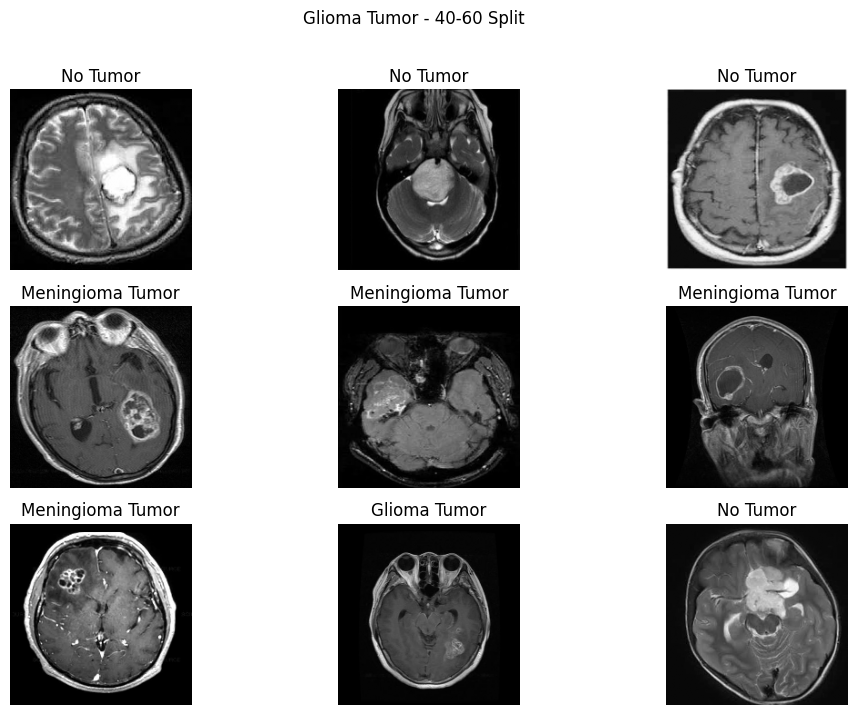

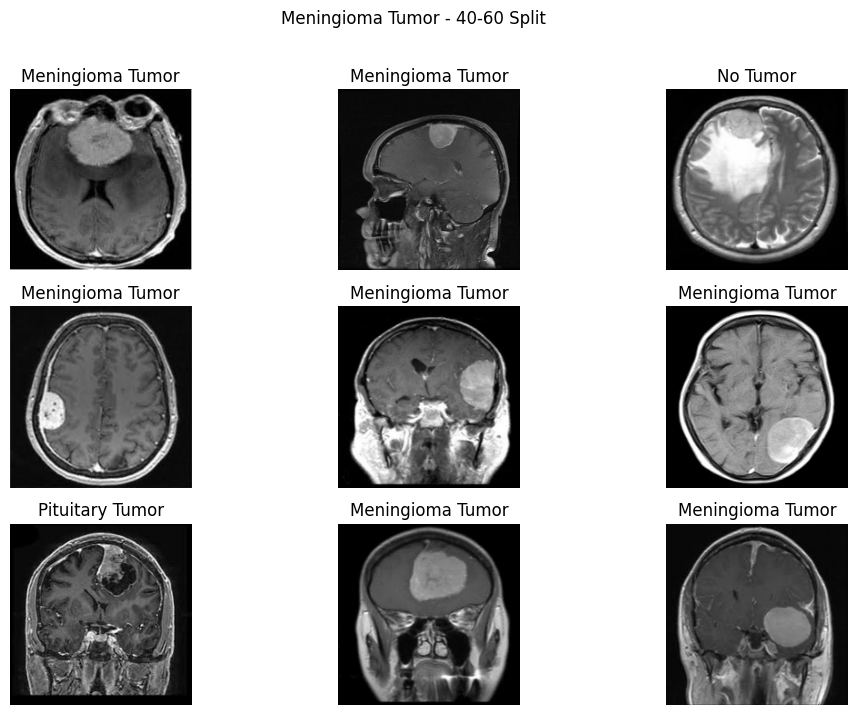


Predictions using LINEAR SVM - 60-40 Split


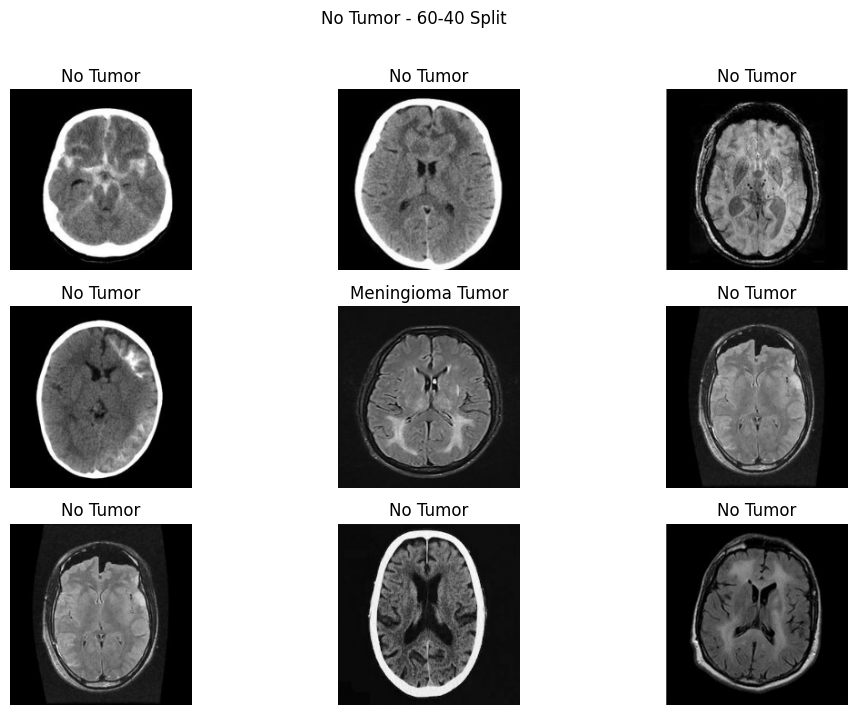

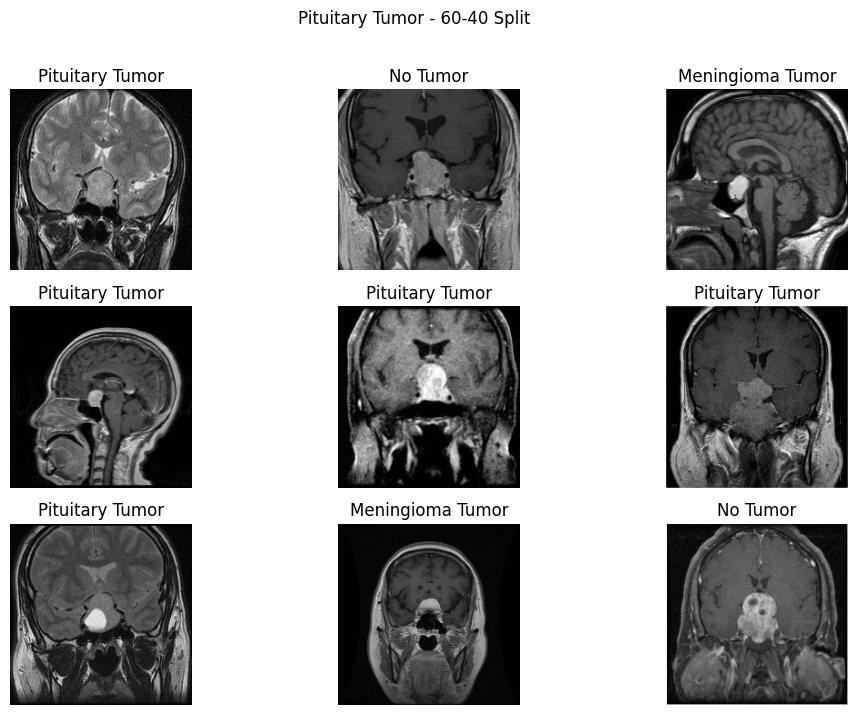

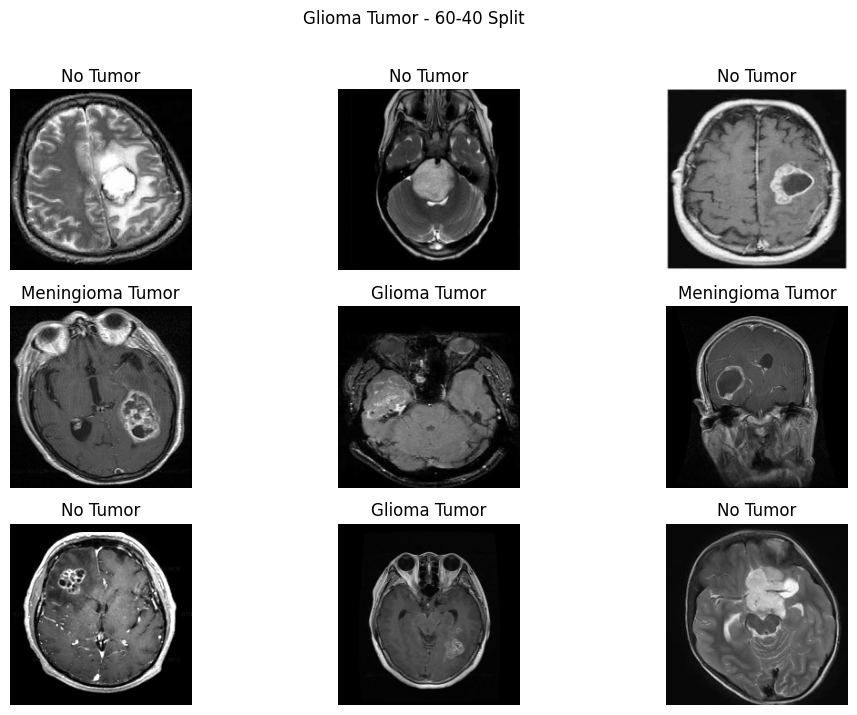

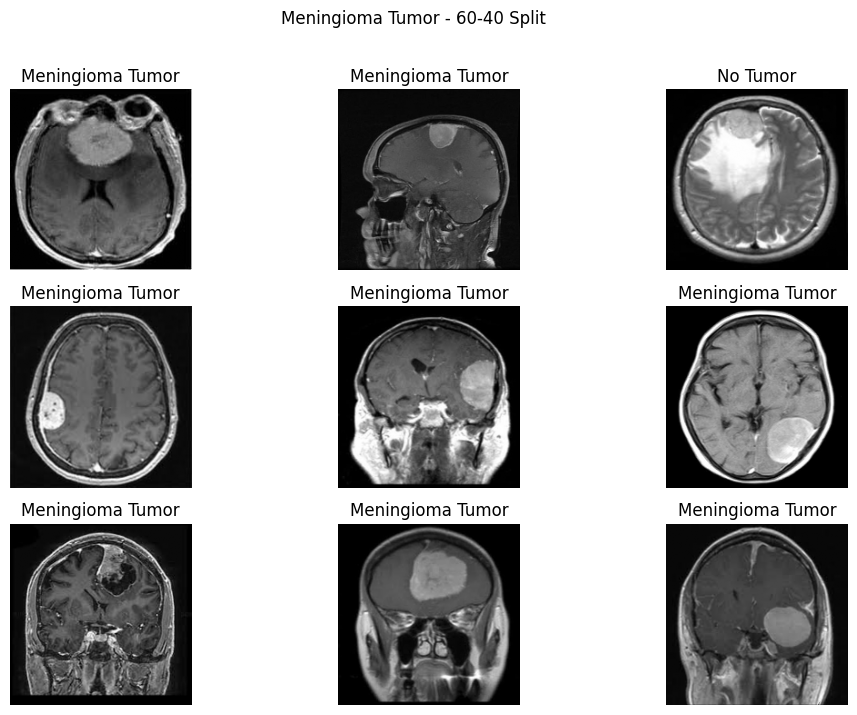


Predictions using LINEAR SVM - 80-20 Split


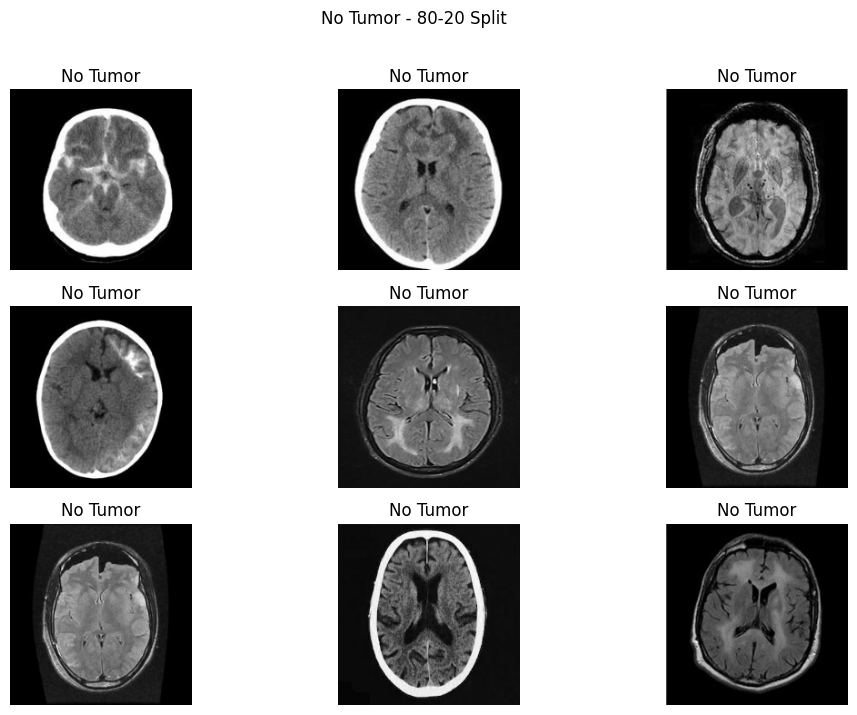

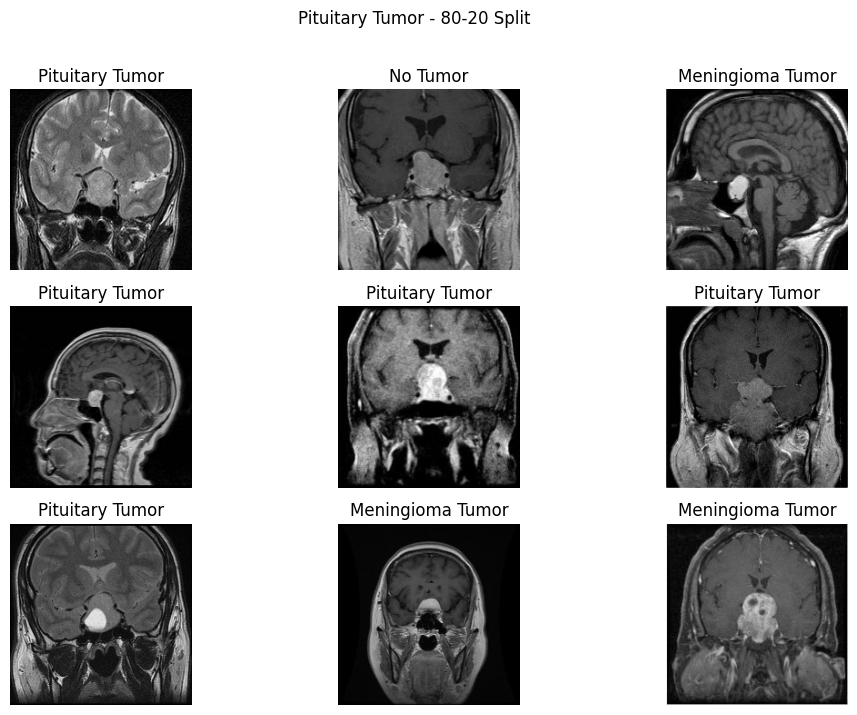

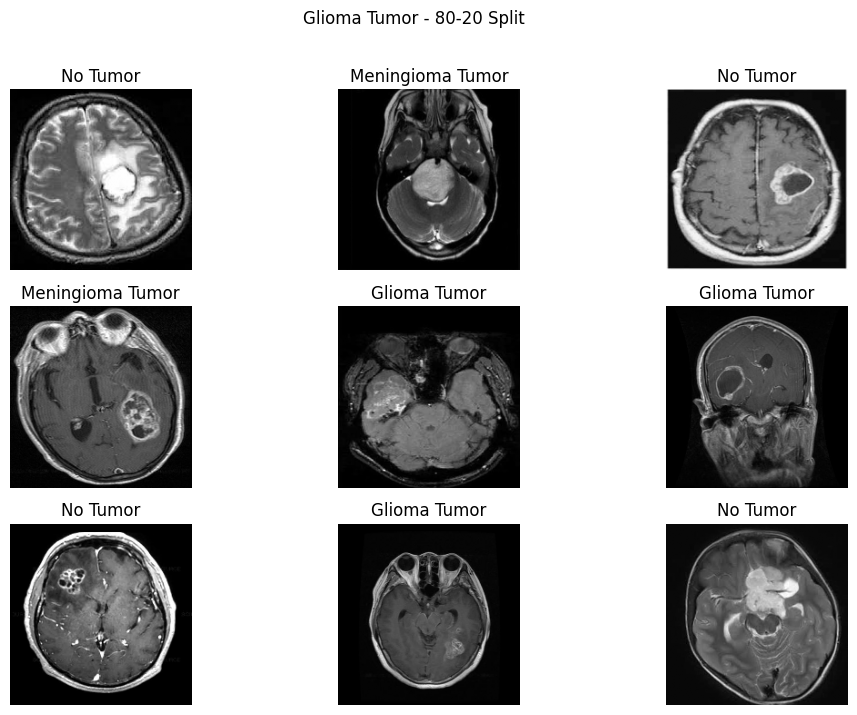

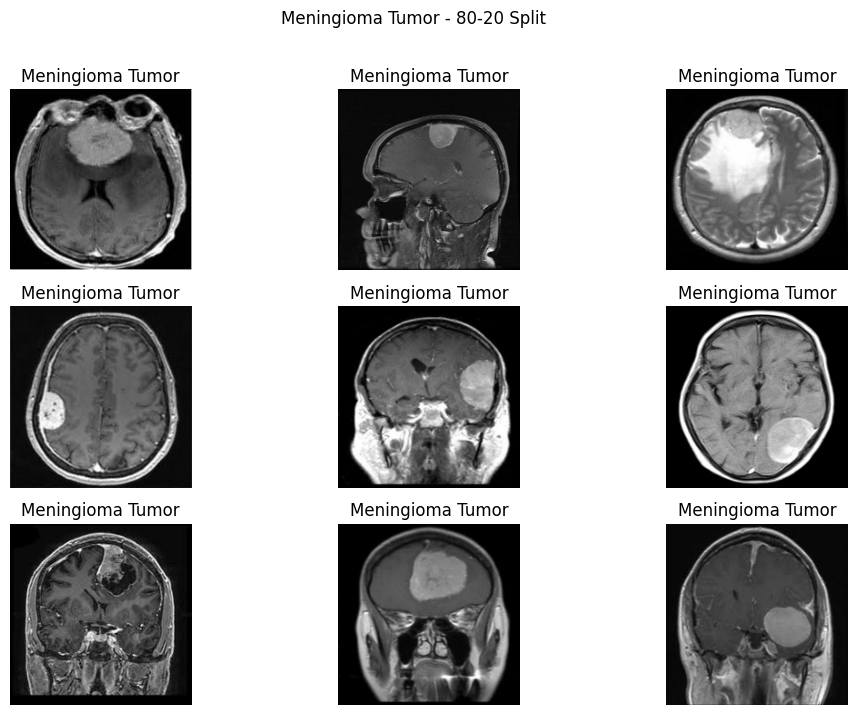

In [10]:
# Define class labels

dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

# Get testing dataset path

test_path = os.path.join(path, "Testing")

# Different train-test splits

splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2
}

tumor_folders = [
    'no_tumor',
    'pituitary_tumor',
    'glioma_tumor',
    'meningioma_tumor'
]

for split_name, test_size in splits.items():

    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=10,
        test_size=test_size
    )

    pca = PCA(n_components=0.98)

    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(xtest)

    sv = SVC(kernel='linear')

    sv.fit(pca_train, ytrain)

    print(f"\nPredictions using LINEAR SVM - {split_name}")

    for tumor_folder in tumor_folders:

        folder_path = os.path.join(test_path, tumor_folder)

        title = (
            f'{tumor_folder.replace("_", " ").title()} '
            f'- {split_name}'
        )

        display_samples(folder_path, title, sv, pca)

In [11]:
import pandas as pd

# Different train-test splits

splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2}
for split_name, test_size in splits.items():
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=10,
        test_size=test_size)
    tumor_counts = {
        dec[label]: np.sum(ytrain == label)
        for label in classes.values()}
    table_data = {
        'Index': range(1, len(classes) + 1),
        'Tumor Type': list(tumor_counts.keys()),
        'Count': list(tumor_counts.values())}
    tumor_table = pd.DataFrame(table_data)
    styled_table = tumor_table.style.set_properties(
        **{
            'border': '3px solid black',
            'text-align': 'center'})
    print(f"\nTumor Type Counts - {split_name}")
    display(styled_table)


Tumor Type Counts - 20-80 Split


,Index,Tumor Type,Count
0,1,No Tumor,78
1,2,Pituitary Tumor,148
2,3,Glioma Tumor,183
3,4,Meningioma Tumor,165



Tumor Type Counts - 40-60 Split


,Index,Tumor Type,Count
0,1,No Tumor,144
1,2,Pituitary Tumor,324
2,3,Glioma Tumor,352
3,4,Meningioma Tumor,328



Tumor Type Counts - 60-40 Split


,Index,Tumor Type,Count
0,1,No Tumor,221
1,2,Pituitary Tumor,489
2,3,Glioma Tumor,514
3,4,Meningioma Tumor,498



Tumor Type Counts - 80-20 Split


,Index,Tumor Type,Count
0,1,No Tumor,304
1,2,Pituitary Tumor,665
2,3,Glioma Tumor,681
3,4,Meningioma Tumor,646


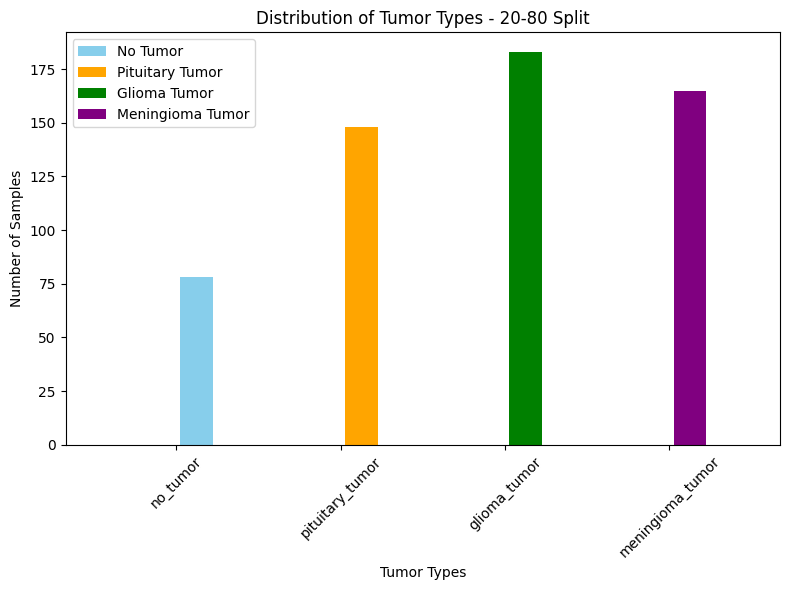

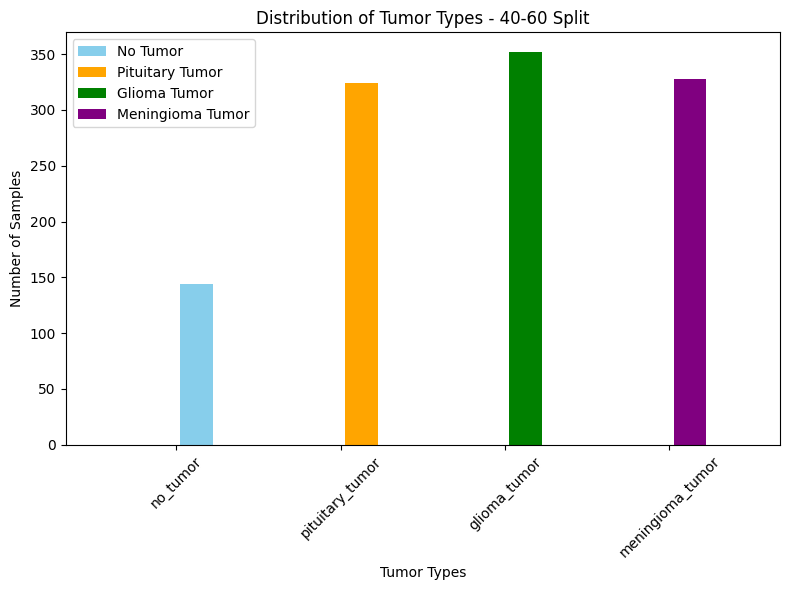

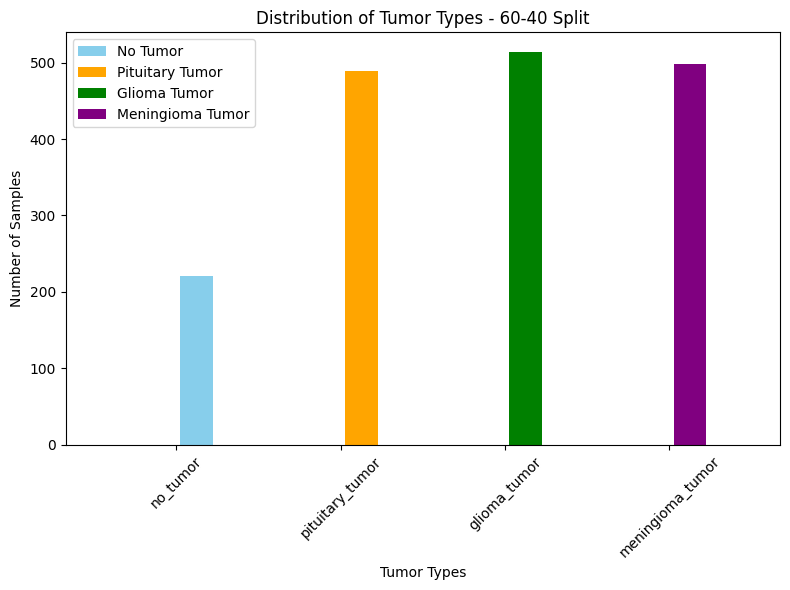

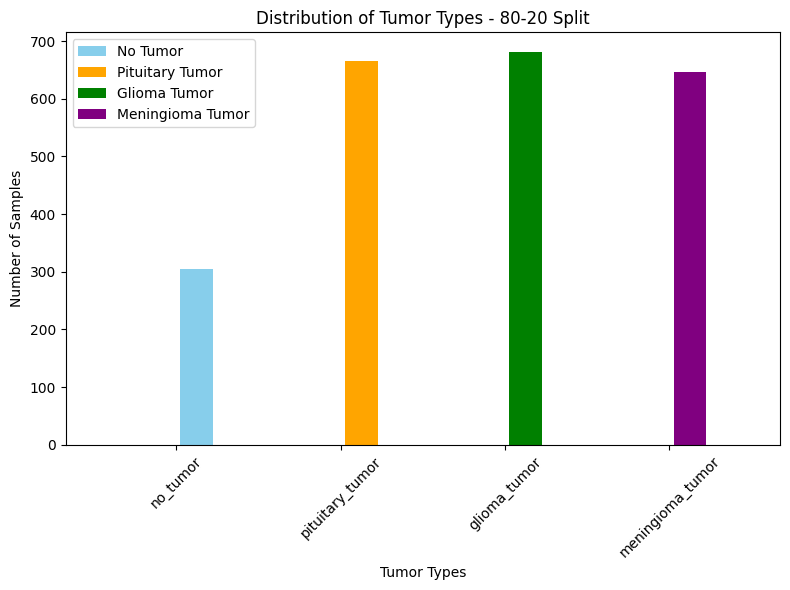

In [12]:
# Create histogram of tumor types for different train-test splits
colors = ['skyblue', 'orange', 'green', 'purple']
splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2}
for split_name, test_size in splits.items():
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=10,
        test_size=test_size)
    tumor_labels = [dec[label] for label in ytrain]
    plt.figure(figsize=(8, 6))

    for label, color in zip(classes.values(), colors):
        plt.hist(
            np.array(tumor_labels)[ytrain == label],
            bins=len(classes),
            align='mid',
            rwidth=0.8,
            color=color,
            label=dec[label])

    plt.xlabel('Tumor Types')
    plt.ylabel('Number of Samples')
    plt.title(f'Distribution of Tumor Types - {split_name}')
    plt.xticks(
        range(len(classes)),
        list(classes.keys()),
        rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np
train_sizes = [0.2, 0.4, 0.6, 0.8]
for train_size in train_sizes:
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=10,
        stratify=Y)
    pca = PCA(n_components=0.98)
    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(xtest)
    svm_linear = SVC(kernel='linear')
    svm_linear.fit(pca_train, ytrain)
    ypred_linear = svm_linear.predict(pca_test)
    accuracy_linear = accuracy_score(
        ytest,
        ypred_linear)
    f1_linear = f1_score(
        ytest,
        ypred_linear,
        average='weighted')
    cm_linear = confusion_matrix(
        ytest,
        ypred_linear)
    sensitivity_linear = np.mean(
        cm_linear.diagonal() / cm_linear.sum(axis=1))
    specificity_linear = np.mean([
        (np.sum(cm_linear) - (
            cm_linear[i,:].sum() +
            cm_linear[:,i].sum() -
            cm_linear[i,i]
        )) /
        (np.sum(cm_linear) - cm_linear[i,:].sum())
        for i in range(len(cm_linear))
    ])
    print(
        f"\nLinear Kernel - "
        f"{int(train_size*100)}% Training Data")
    print("Accuracy:", accuracy_linear)
    print("F1-Score:", f1_linear)
    print("Sensitivity:", sensitivity_linear)
    print("Specificity:", specificity_linear)


Linear Kernel - 20% Training Data
Accuracy: 0.7290940766550522
F1-Score: 0.7243899682330085
Sensitivity: 0.7151243723025037
Specificity: 0.9077475658897677

Linear Kernel - 40% Training Data
Accuracy: 0.772938443670151
F1-Score: 0.7687522412741843
Sensitivity: 0.7626907886399797
Specificity: 0.9226095390939819

Linear Kernel - 60% Training Data
Accuracy: 0.7952961672473867
F1-Score: 0.7935016343665066
Sensitivity: 0.7846666891253031
Specificity: 0.9303730124792632

Linear Kernel - 80% Training Data
Accuracy: 0.8275261324041812
F1-Score: 0.8256782197054756
Sensitivity: 0.8120636747219026
Specificity: 0.9407609098318144
